Test 3 : LoghtGBM

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [3]:
df = df.drop(columns=['_id_x', '_id_y'])

# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

In [4]:
# Time features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

# Lag features
df['lag_1'] = df['wdLoad'].shift(1)
df['lag_24'] = df['wdLoad'].shift(24)
df['lag_168'] = df['wdLoad'].shift(168)

# Rolling features
df['rolling_mean_24'] = df['wdLoad'].rolling(24).mean()

# Drop NaNs
df = df.dropna()

In [5]:
df['lag_48'] = df['wdLoad'].shift(48)

In [6]:
df['rolling_std_24'] = df['wdLoad'].rolling(24).std()

In [7]:
df['is_weekend'] = df.index.dayofweek >= 5


In [8]:
train = df[:'2024']
test = df['2025':]

X_train = train.drop(columns=['wdLoad'])
y_train = train['wdLoad']

X_test = test.drop(columns=['wdLoad'])
y_test = test['wdLoad']

In [9]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2086
[LightGBM] [Info] Number of data points in the train set: 245326, number of used features: 12
[LightGBM] [Info] Start training from score 315.356972


LGBMRegressor(learning_rate=0.05, max_depth=7, n_estimators=1000,
              random_state=42)

In [10]:
preds = model.predict(X_test)

In [13]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test)

print(result.importances_mean)

[1.53661031e-03 1.20633844e-05 1.36628019e-02 3.78620319e-04
 5.24325788e-05 1.80257653e+00 7.28999634e-04 4.30943681e-04
 3.39937875e-03 1.05306593e-03 1.76459730e-03 0.00000000e+00]


In [18]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    mode='regression',
    discretize_continuous=False   # 🔥 IMPORTANT FIX
)

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict
)

print(exp.as_list())

[('lag_1', 81.73603822528783), ('hour', -3.534598891520789), ('rolling_std_24', -1.2526775528583187), ('lag_24', 0.6014606738571555), ('rolling_mean_24', -0.6008816759052603), ('lag_48', 0.579779373258698), ('temp', 0.521940450891724), ('rh', -0.3657449037900011), ('month', 0.19179879956962329), ('lag_168', -0.11275123980825015)]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


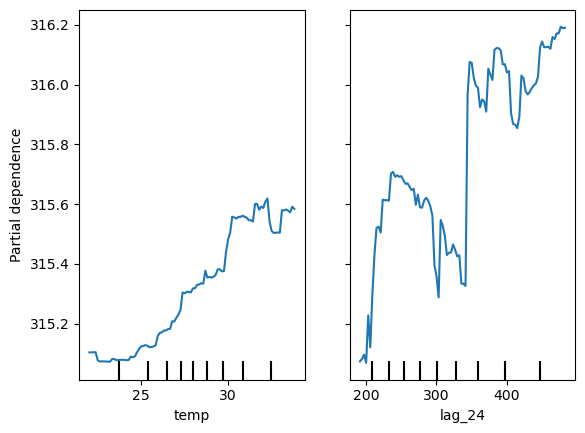

In [15]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model, X_train, ['temp', 'lag_24']
)

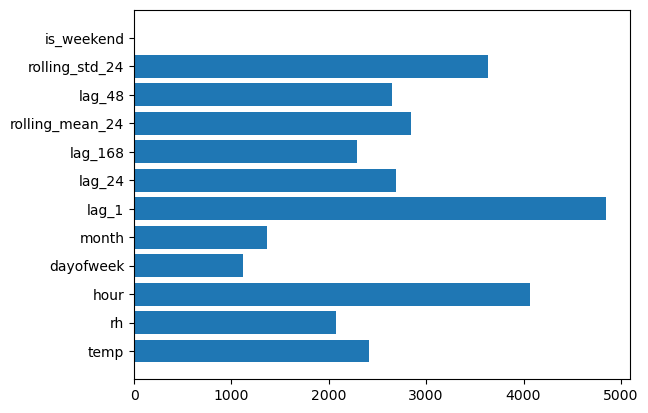

array([6.03632740e+05, 4.19169672e+05, 4.93276304e+07, 4.89953685e+05,
       2.99361413e+05, 2.06825962e+10, 3.70771735e+06, 1.24420338e+06,
       4.19303460e+06, 1.58837612e+06, 1.90336363e+06, 0.00000000e+00])

In [16]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(X_train.columns, importance)
plt.show()
model.booster_.feature_importance(importance_type='gain')

In [20]:
import shap

explainer = shap.TreeExplainer(
    model.booster_,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_test)

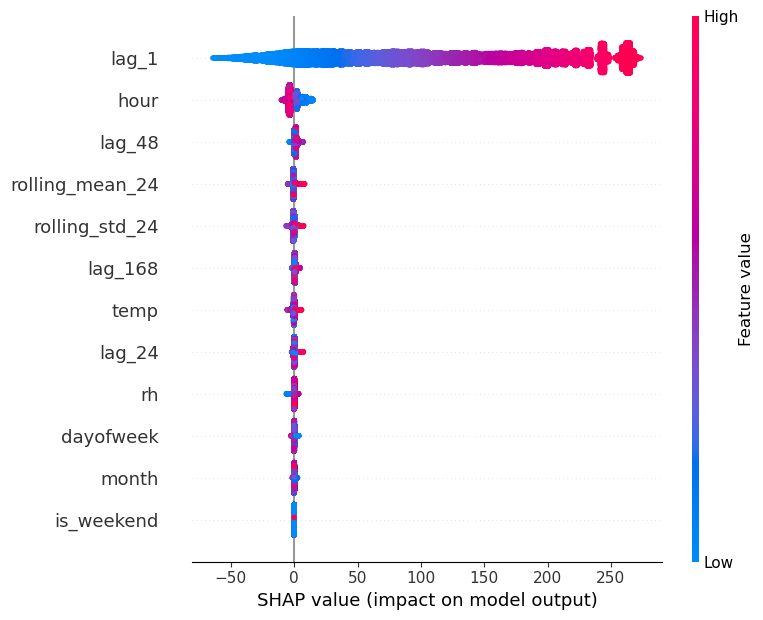

In [21]:
shap.summary_plot(shap_values, X_test)

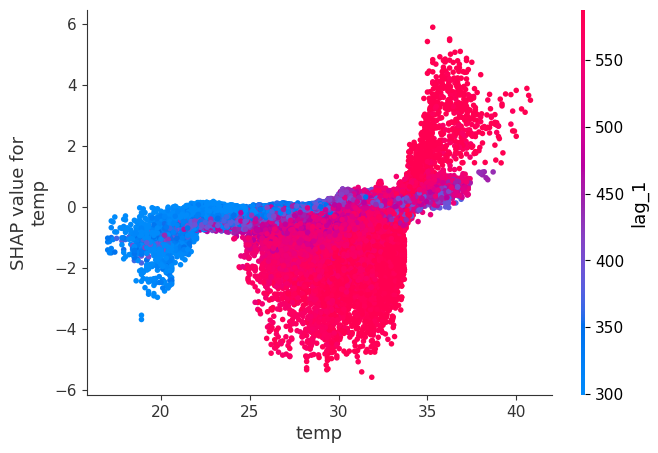

In [24]:
shap.dependence_plot("temp", shap_values, X_test)